# PUCSL Sri Lanka Dispatch — Multi-Year Exploratory Data Analysis

**Module:** 7COSC013W.1 Foundations of AI · **Student:** Danuja Wijerathna (20251143)
**Candidate CW1 topic:** unit commitment / economic dispatch of the Sri Lankan power system,
benchmarked against what the Ceylon Electricity Board actually dispatched.

**Source:** PUCSL Electricity Dispatch Data portal (`gendata.pucsl.gov.lk`), the Sri Lankan
electricity regulator. Undocumented public JSON API, no key.

**Fully offline.** Reads only `pucsl_cache/csv/`, built once by `pucsl_cache.py --export`
from immutable JSON in `pucsl_cache/raw/`. No network call anywhere below.

---

## Why this supersedes the 3-day EDA

The first pass ran on 3 days of January 2023 and produced a headline finding: the day-ahead
series is published at half scale and half resolution, so it must be doubled. **On 1,009 days
of data that finding turns out to be true only for 2023.** PUCSL changed the feed format in
late 2023. Generalising a 3-day result to the whole API was wrong, and §4 documents exactly
where the break is.

That is the central lesson of this notebook: **the dataset is not one homogeneous system.**
It contains structural breaks, and any analysis that pools years without accounting for them
will be wrong.

## Contents

| § | Question |
|---|---|
| 1 | What is actually cached, and where are the gaps? |
| 2 | Loading, de-duplication, timezone |
| 3 | Profiling every table |
| 4 | **Structural break 1** — the day-ahead format change (supersedes the 3-day finding) |
| 5 | **Structural break 2** — rooftop solar enters the feed |
| 6 | Are the years the same system? Plant sets, load, mix |
| 7 | Grid events — two nationwide blackouts, captured at 15-min |
| 8 | Load characterisation: seasonal, weekly, daily, duration curve |
| 9 | Commitment behaviour — the modelling target |
| 10 | Consistency checks |
| 11 | **Which data should this project use?** — evidence-based recommendation |
| 12 | Data limitations |

## 1. Dependencies

Checks what is already installed and installs only what is missing, so a re-run on a machine
that already has them costs nothing and prints one line. `scipy` carries a floor because the
exact solver in section 7 uses `scipy.optimize.milp`, which does not exist before 1.9.

In [1]:
import importlib.util

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy>=1.9",
    "sklearn": "scikit-learn",
    "networkx": "networkx",
    "yaml": "pyyaml",
}

missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]

if missing:
    print("installing:", ", ".join(missing))
    !pip install --quiet {" ".join(missing)}
    print("done")
else:
    print("all packages already installed")

all packages already installed


## 2. Code and data

Fetched only when they are not already beside the notebook, so this does nothing on a machine
with the project checked out. The bundle holds the analysis package, the derived CSVs, the cost
tables and the cached result tables. The raw API responses are about a gigabyte and are
deliberately not included; the CSVs derived from them are, and the manifest records what was
fetched.

The bundle is hosted for 30 days from 9 August 2026 and is then deleted automatically, so this
will report an error after roughly 8 September 2026. That is expected. Run the notebook from the
project directory instead, where the files are already present and nothing is downloaded.

In [2]:
import io
import pathlib
import sys
import tarfile
import urllib.error
import urllib.request

BUNDLE_URL = (
    "https://dispatch-lab-demo-600307630560.s3.ap-south-1.amazonaws.com"
    "/bundle-b9b9578e278c3389/dispatch-lab-bundle.tar.gz"
)

ROOT = pathlib.Path.cwd()
# One file stands for the whole bundle. If the biggest data file is here, everything is.
if (ROOT / "pucsl_cache" / "csv" / "actual_15min.csv").exists():
    print("project files: already present")
else:
    print("project files: fetching bundle, about 24 MB ...")
    try:
        with urllib.request.urlopen(BUNDLE_URL) as response:
            payload = response.read()
    except urllib.error.HTTPError as err:
        raise RuntimeError(
            f"bundle unavailable ({err.code}). It is hosted for 30 days from 9 August 2026 and is "
            "then deleted. Run this notebook from the project directory, where the data is already "
            "present and no download is needed."
        ) from None
    with tarfile.open(fileobj=io.BytesIO(payload)) as archive:
        # `filter="data"` refuses absolute paths and parent traversal. It is the default from
        # Python 3.14 and unavailable before 3.11.4, so it is requested rather than assumed.
        try:
            archive.extractall(ROOT, filter="data")
        except TypeError:
            archive.extractall(ROOT)
    print(f"project files: unpacked into {ROOT}")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

project files: already present


In [3]:
# --- Setup ------------------------------------------------------------------------------------
import json
import os
import random
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
CSV = ROOT / "pucsl_cache" / "csv"
RAW = ROOT / "pucsl_cache" / "raw"
FIG = ROOT / "pucsl_cache" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

LK = "Asia/Colombo"      # UTC+05:30. The 15-min timestamps are TRUE UTC.
STEP_H = 0.25            # 15 minutes in hours - the MW -> MWh factor

# Validated categorical palette (dataviz reference, light surface), fixed order, never cycled.
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER, SURFACE, INK, INK2, GRID = "#8a8a86", "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2df"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
GOOD, BAD = "#1baf7a", "#e34948"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "lines.linewidth": 1.8,
})


def save(fig, name):
    p = FIG / name
    fig.savefig(p)
    print(f"  figure -> {p.relative_to(ROOT)}")
    return p


def rule(t):
    print("\n" + "=" * 100 + f"\n{t}\n" + "=" * 100)


print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} "
      f"| matplotlib {mpl.__version__}")
print(f"seed={SEED} | offline: no network calls in this notebook")

python 3.13.9 | pandas 2.3.3 | numpy 2.3.5 | matplotlib 3.10.6
seed=42 | offline: no network calls in this notebook


## 1. What is cached, and where are the gaps?

In [4]:
rule("1. CACHE INVENTORY AND COVERAGE")

man = json.loads((ROOT / "pucsl_cache" / "manifest.json").read_text())
raw_files = list(RAW.glob("*.json"))
print(f"manifest: {len(man['ok'])} keys OK, {len(man['failed'])} failed {man['failed']}")
if raw_files:
    print(f"raw responses: {len(raw_files)}  "
          f"({sum(f.stat().st_size for f in raw_files)/1e6:.0f} MB)")
else:
    # The raw JSON cache is about a gigabyte and is not shipped in the portable
    # bundle, only the CSVs derived from it. The manifest records exactly which
    # responses were fetched, so the inventory is reported from there instead of
    # silently printing zero.
    print(f"raw responses: {len(man['ok'])} recorded in the manifest "
          f"(raw JSON not bundled, CSVs derived from it are)")
for kind in ("actual", "dayahead", "dailystats", "emissions"):
    n = len(list(RAW.glob(f"{kind}_2*.json"))) or \
        len([k for k in man["ok"] if k.startswith(f"{kind}_2")])
    print(f"  {kind:11s} {n:5d} files")


1. CACHE INVENTORY AND COVERAGE
manifest: 2688 keys OK, 4 failed ['dailystats_2016-01', 'dailystats_2016-02', 'emissions_2016-01', 'emissions_2016-02']
raw responses: 2688  (1044 MB)
  actual       1300 files
  dayahead     1300 files
  dailystats     43 files
  emissions      43 files


In [5]:
rule("2. LOADING  (de-duplicate overlapping day-files, localise to Asia/Colombo)")


def load_15min(fname, label):
    df = pd.read_csv(CSV / fname, parse_dates=["timestamp_utc"])
    n0 = len(df)
    dup = df.duplicated(["timestamp_utc", "plant_id"], keep=False)
    disagree = 0
    if dup.any():
        disagree = int(df[dup].groupby(["timestamp_utc", "plant_id"])["mw"].nunique().gt(1).sum())
    df = df.drop_duplicates(["timestamp_utc", "plant_id"]).copy()
    df["ts"] = df["timestamp_utc"].dt.tz_convert(LK)
    df["date"] = df["ts"].dt.date
    df["y"] = df["ts"].dt.year
    df["ym"] = df["ts"].dt.strftime("%Y-%m")
    print(f"{label:9s} {n0:,} -> {len(df):,} rows after de-dup "
          f"({n0-len(df):,} dropped, {disagree} value conflicts)")
    return df


plants = pd.read_csv(CSV / "plants.csv")
PMETA = plants.set_index("plant_id")
ACT = load_15min("actual_15min.csv", "actual")
DAH = load_15min("dayahead_15min.csv", "dayahead")
daily = pd.read_csv(CSV / "daily_stats.csv", parse_dates=["date_lk"])
daily["date_lk"] = daily["date_lk"].dt.date
emis = pd.read_csv(CSV / "emissions.csv", parse_dates=["report_date"])

for d in (ACT, DAH):
    d["et"] = d["plant_id"].map(PMETA["energy_type"])
assert ACT.et.isna().sum() == 0, "unmapped energy_type - metadata join is broken"

LOAD = ACT.groupby("ts")["mw"].sum().sort_index()          # system MW per interval
PLAN = DAH.groupby("ts")["mw"].sum().sort_index()

print(f"\ncoverage: {ACT.ts.min()}  ->  {ACT.ts.max()}")
print(f"local dates: {ACT.date.nunique():,}   intervals: {len(LOAD):,}")


2. LOADING  (de-duplicate overlapping day-files, localise to Asia/Colombo)


actual    3,573,383 -> 3,536,628 rows after de-dup (36,755 dropped, 0 value conflicts)


dayahead  3,957,018 -> 3,916,474 rows after de-dup (40,544 dropped, 0 value conflicts)



coverage: 2023-01-01 05:30:00+05:30  ->  2026-07-24 05:30:00+05:30
local dates: 1,009   intervals: 96,674


In [6]:
# --- coverage by month, and the gap ----------------------------------------------------------
per_day = ACT.groupby("date")["ts"].nunique()
FULL_DAYS = set(per_day[per_day >= 96].index)
cov = pd.DataFrame({
    "days": ACT.groupby("ym")["date"].nunique(),
    "full_days": ACT[ACT.date.isin(FULL_DAYS)].groupby("ym")["date"].nunique(),
}).fillna(0).astype(int)
cov["intervals"] = ACT.groupby("ym")["ts"].nunique()
print(cov.to_string())

dates = sorted(ACT.date.unique())
gaps = [(dates[i-1], dates[i], (dates[i]-dates[i-1]).days - 1)
        for i in range(1, len(dates)) if (dates[i]-dates[i-1]).days > 1]
print(f"\ntotal local dates {len(dates):,} | complete (96 intervals) {len(FULL_DAYS):,}")
print("GAPS:")
for g in gaps:
    print(f"   {g[0]} -> {g[1]}   {g[2]} days missing")
print("\n  The gap is the 2025 fetch that the API outage interrupted. It matters for")
print("  continuous time-series work; it does NOT matter for unit commitment, which is")
print("  solved one day at a time - every day is an independent problem instance.")

         days  full_days  intervals
ym                                 
2023-01    31         30       2954
2023-02    28         28       2688
2023-03    31         31       2976
2023-04    30         30       2880
2023-05    31         31       2976
2023-06    30         30       2880
2023-07    31         31       2976
2023-08    31         31       2976
2023-09    30         30       2880
2023-10    31         31       2976
2023-11    30         30       2880
2023-12    31         31       2976
2024-01    31         31       2976
2024-02    29         29       2784
2024-03    31         31       2976
2024-04    30         30       2880
2024-05    31         31       2976
2024-06    30         30       2880
2024-07    31         31       2976
2024-08    31         31       2976
2024-09    30         30       2880
2024-10    31         31       2976
2024-11    30         30       2880
2024-12    31         31       2976
2025-01    31         31       2976
2025-02    28         28    

## 3. Profiling

In [7]:
rule("3. COLUMN PROFILES")


def profile(df, name, keys=None):
    print(f"\n--- {name}  {df.shape[0]:,} x {df.shape[1]} "
          f"({df.memory_usage(deep=True).sum()/1e6:.0f} MB) ---")
    rows = []
    for c in df.columns:
        s = df[c]
        r = {"column": c, "dtype": str(s.dtype), "nulls": int(s.isna().sum()),
             "null_%": round(100*s.isna().mean(), 2), "nunique": int(s.nunique(dropna=True))}
        if pd.api.types.is_numeric_dtype(s) and s.notna().any():
            r |= {"min": round(float(s.min()), 2), "median": round(float(s.median()), 2),
                  "max": round(float(s.max()), 2)}
        rows.append(r)
    print(pd.DataFrame(rows).fillna("").to_string(index=False))
    if keys:
        print(f"  key {keys}: {df.duplicated(keys).sum()} duplicates")


profile(ACT[["timestamp_utc", "plant_id", "mw"]], "actual_15min", ["timestamp_utc", "plant_id"])
profile(DAH[["timestamp_utc", "plant_id", "mw"]], "dayahead_15min", ["timestamp_utc", "plant_id"])
profile(daily, "daily_stats", ["date_lk", "plant_id"])
profile(emis, "emissions", ["report_date", "plant_id"])
profile(plants, "plants")


3. COLUMN PROFILES

--- actual_15min  3,536,628 x 3 (113 MB) ---


       column               dtype  nulls  null_%  nunique   min median     max
timestamp_utc datetime64[ns, UTC]      0    0.00    96674                     
     plant_id               int64      0    0.00       45   1.0   29.0   106.0
           mw             float64   3137    0.09     1608 -24.0   16.0  1664.0


  key ['timestamp_utc', 'plant_id']: 0 duplicates

--- dayahead_15min  3,916,474 x 3 (125 MB) ---


       column               dtype  nulls  null_%  nunique   min median     max
timestamp_utc datetime64[ns, UTC]      0    0.00    95910                     
     plant_id               int64      0    0.00       47   1.0   32.0   106.0
           mw             float64  67982    1.74   141180 -20.0    0.0  1749.5


  key ['timestamp_utc', 'plant_id']: 0 duplicates

--- daily_stats  53,255 x 4 (3 MB) ---
               column   dtype  nulls  null_%  nunique  min median      max
              date_lk  object      0     0.0     1274                     
             plant_id   int64      0     0.0       52  1.0   28.0    106.0
           energy_mwh float64    375     0.7     5648  0.0  512.0  12338.0
available_capacity_mw float64    375     0.7      288  0.0   48.0    312.0
  key ['date_lk', 'plant_id']: 1650 duplicates

--- emissions  3,185 x 6 (0 MB) ---
     column               dtype  nulls  null_%  nunique      min median       max
report_date datetime64[ns, UTC]      0    0.00     1130                          
   plant_id               int64      0    0.00        3     32.0   33.0      34.0
 nox_mg_nm3             float64    324   10.17     1688      0.0  62.75    684.29
 so2_mg_nm3             float64    324   10.17     1757 -4900.44   8.15  29641.27
  co_mg_nm3             float64    324   

## 4. Structural break 1 — the day-ahead format changed in late 2023

The 3-day EDA concluded that `day-ahead-dispatch.powerInMw` is published as **MWh per
half-hour** (half the MW value, repeated onto 15-minute stamps) and must be doubled. That
conclusion was drawn from 1–3 January 2023 and was **correct for that window**.

With 1,009 days it is now testable properly, and the picture is different: **PUCSL changed the
feed.** Two independent signals are tracked per month:

* **scale** — median ratio `actual / day-ahead` of system totals (2.0 = half-scale, 1.0 = correct);
* **resolution** — where value changes fall. A natively half-hourly series can only change at
  `:00` and `:30`; a true 15-minute series changes at all four positions.

In [8]:
rule("4. DAY-AHEAD SCALE AND RESOLUTION, BY MONTH")

cmp_ = pd.concat([LOAD.rename("act"), PLAN.rename("dah")], axis=1).dropna()
cmp_ = cmp_[cmp_.act > 200]                       # exclude blackout / boundary intervals
cmp_["ym"] = cmp_.index.strftime("%Y-%m")

WD = DAH.pivot_table(index="ts", columns="plant_id", values="mw", aggfunc="first").sort_index()
chg = (WD.diff().fillna(0) != 0)
chg_min = pd.Series(WD.index.minute, index=WD.index)

rows = []
for ym, g in cmp_.groupby("ym"):
    ratio = (g.act / g.dah).replace([np.inf, -np.inf], np.nan).dropna().median()
    sel = chg.loc[chg_min.index.strftime("%Y-%m") == ym]
    mins = chg_min[chg_min.index.strftime("%Y-%m") == ym]
    c = {m: int(sel[mins == m].values.sum()) for m in (0, 15, 30, 45)}
    odd, even = c[15] + c[45], c[0] + c[30]
    native = "30-min" if even > 0 and odd < 0.15 * even else "15-min"
    rows.append({"month": ym, "act/dah": round(ratio, 3),
                 "scale": "HALF (needs x2)" if ratio > 1.7 else
                          ("OK" if 0.9 < ratio < 1.15 else f"odd {ratio:.2f}"),
                 ":00": c[0], ":15": c[15], ":30": c[30], ":45": c[45], "native": native,
                 "MAE_raw": round((g.act - g.dah).abs().mean()),
                 "MAE_x2": round((g.act - 2 * g.dah).abs().mean())})
fmt = pd.DataFrame(rows).set_index("month")
print(fmt.to_string())

HALF = fmt[fmt.scale.str.startswith("HALF")].index.tolist()
OKM = fmt[fmt.scale == "OK"].index.tolist()
print(f"\nHALF-SCALE months ({len(HALF)}): {HALF[0]} .. {HALF[-1]}")
print(f"CORRECT months   ({len(OKM)}): {OKM[0]} .. {OKM[-1]}")
print(f"\n-> the feed changed at {HALF[-1]} / {OKM[0]}.")


4. DAY-AHEAD SCALE AND RESOLUTION, BY MONTH


         act/dah            scale   :00   :15   :30   :45  native  MAE_raw  MAE_x2
month                                                                             
2023-01    1.998  HALF (needs x2)  3952     0  3609     0  30-min      760     134
2023-02    1.983  HALF (needs x2)  3951     0  3534     0  30-min      801     140
2023-03    1.997  HALF (needs x2)  4636     0  4246     0  30-min      822      59
2023-04    1.954  HALF (needs x2)  4362     0  4238     0  30-min      769      97
2023-05    1.994  HALF (needs x2)  4920     0  4583     0  30-min      844     179
2023-06    1.962  HALF (needs x2)  5251     0  4850     0  30-min      790      72
2023-07    1.984  HALF (needs x2)  5266     0  4884     0  30-min      813     118
2023-08    1.993  HALF (needs x2)  5114     0  4674     0  30-min      845      74
2023-09    1.943  HALF (needs x2)  4698     0  4522     0  30-min      714      92
2023-10    1.963  HALF (needs x2)  4389     0  4176     0  30-min      713      63
2023

In [9]:
rule("4b. WHAT THIS MEANS")

for lab, months in (("2023 half-scale era", HALF), ("2023-12 onward, corrected feed", OKM)):
    sub = cmp_[cmp_.ym.isin(months)]
    if not len(sub):
        continue
    mae_raw = (sub.act - sub.dah).abs().mean()
    mae_x2 = (sub.act - 2 * sub.dah).abs().mean()
    best = min(mae_raw, mae_x2)
    print(f"\n{lab}   ({len(sub):,} intervals)")
    print(f"   actual mean {sub.act.mean():7.0f} MW | day-ahead mean {sub.dah.mean():7.0f} MW")
    print(f"   MAE as published {mae_raw:6.0f} MW | MAE if doubled {mae_x2:6.0f} MW"
          f"  -> {'DOUBLE IT' if mae_x2 < mae_raw else 'DO NOT DOUBLE'}")
    print(f"   best MAE = {best:.0f} MW = {100*best/sub.act.mean():.1f}% of mean load")

print("""
CONCLUSION - this supersedes the 3-day finding:

  * Jan-Nov 2023 : day-ahead is published at HALF scale and is natively HALF-HOURLY.
                   Multiply by 2. (The 3-day EDA sampled here, so it was right locally.)
  * Dec 2023 on  : the feed is CORRECT - true 15-minute, correct MW. Doubling it would
                   introduce a ~100% error. The 3-day rule must NOT be applied here.

  Applying the x2 rule blindly across all years would corrupt every post-2023 comparison.
  This is the single most important correction in this notebook.
""")


4b. WHAT THIS MEANS

2023 half-scale era   (31,969 intervals)
   actual mean    1561 MW | day-ahead mean     784 MW
   MAE as published    779 MW | MAE if doubled    149 MW  -> DOUBLE IT
   best MAE = 149 MW = 9.6% of mean load

2023-12 onward, corrected feed   (63,894 intervals)
   actual mean    1872 MW | day-ahead mean    1848 MW
   MAE as published    112 MW | MAE if doubled   1869 MW  -> DO NOT DOUBLE
   best MAE = 112 MW = 6.0% of mean load

CONCLUSION - this supersedes the 3-day finding:

  * Jan-Nov 2023 : day-ahead is published at HALF scale and is natively HALF-HOURLY.
                   Multiply by 2. (The 3-day EDA sampled here, so it was right locally.)
  * Dec 2023 on  : the feed is CORRECT - true 15-minute, correct MW. Doubling it would
                   introduce a ~100% error. The 3-day rule must NOT be applied here.

  Applying the x2 rule blindly across all years would corrupt every post-2023 comparison.
  This is the single most important correction in this notebo

  figure -> pucsl_cache/figures/fig01_dayahead_format_change.png


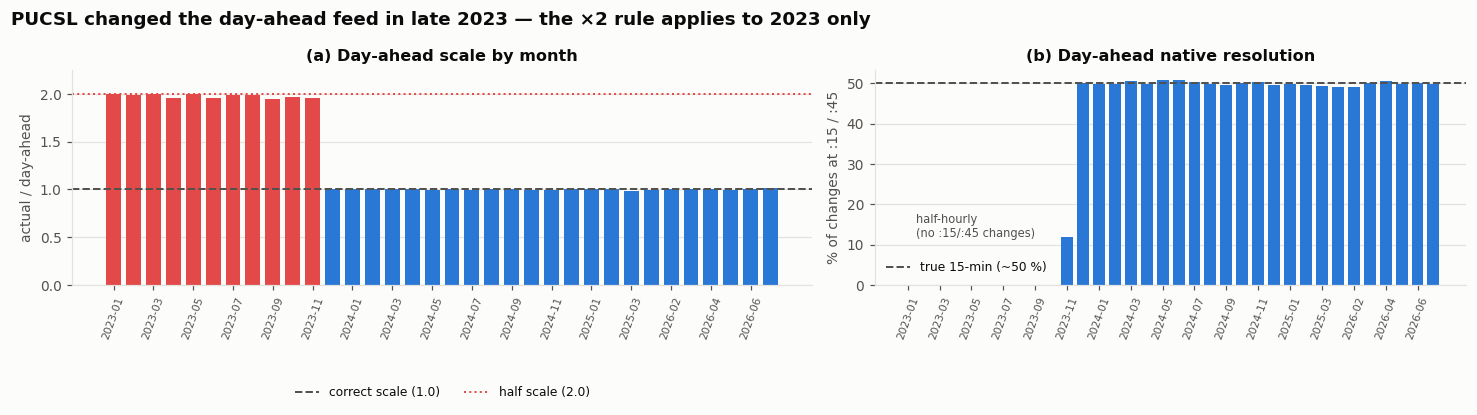

In [10]:
# --- Figure: the format change ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
x = np.arange(len(fmt))
col = [CAT[7] if s.startswith("HALF") else CAT[0] for s in fmt.scale]
ax.bar(x, fmt["act/dah"], color=col, width=0.75)
ax.axhline(1.0, color=INK2, ls="--", lw=1.3, label="correct scale (1.0)")
ax.axhline(2.0, color=CAT[7], ls=":", lw=1.3, label="half scale (2.0)")
ax.set_xticks(x[::2]); ax.set_xticklabels(fmt.index[::2], rotation=70, fontsize=7)
ax.set_ylabel("actual / day-ahead"); ax.set_title("(a) Day-ahead scale by month")
ax.legend(fontsize=8, loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.42))
ax.grid(axis="x", visible=False); ax.set_ylim(0, 2.25)

ax = axes[1]
odd = fmt[":15"] + fmt[":45"]
even = fmt[":00"] + fmt[":30"]
frac = 100 * odd / (odd + even).replace(0, np.nan)
ax.bar(x, frac.fillna(0), color=[CAT[7] if f < 5 else CAT[0] for f in frac.fillna(0)], width=0.75)
ax.axhline(50, color=INK2, ls="--", lw=1.3, label="true 15-min (~50 %)")
ax.set_xticks(x[::2]); ax.set_xticklabels(fmt.index[::2], rotation=70, fontsize=7)
ax.set_ylabel("% of changes at :15 / :45")
ax.set_title("(b) Day-ahead native resolution")
ax.legend(fontsize=8); ax.grid(axis="x", visible=False)
ax.text(0.5, 12, "half-hourly\n(no :15/:45 changes)", fontsize=7.5, color=INK2)

fig.suptitle("PUCSL changed the day-ahead feed in late 2023 — the ×2 rule applies to 2023 only",
             fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout()
save(fig, "fig01_dayahead_format_change.png")
plt.show()

## 5. Structural break 2 — rooftop solar enters the 15-minute feed

The 3-day EDA found solar at 0.7 % of generation and concluded that solar curtailment was not
answerable. That was true of January 2023. It is **not** true of 2026.

In [11]:
rule("5. SOLAR IN THE 15-MINUTE FEED, BY MONTH")

st = ACT.groupby(["ts", "et"])["mw"].sum().unstack("et").fillna(0)
st_m = st.groupby(st.index.strftime("%Y-%m")).mean()
share = 100 * st_m.div(st_m.sum(axis=1), axis=0)
solar_cols = [c for c in share.columns if "Solar" in c]
tab = share[solar_cols].round(2)
tab["ALL SOLAR %"] = tab.sum(axis=1).round(2)
tab["system_MW"] = st_m.sum(axis=1).round(0)
print(tab.to_string())

first_rt = share[[c for c in solar_cols if "Rooftop" in c]].sum(axis=1)
onset = first_rt[first_rt > 1].index.min()
print(f"\n-> rooftop solar first exceeds 1 % of the 15-minute feed in: {onset}")
print(f"   2023-2025 all-solar share: {tab.loc[tab.index < '2026', 'ALL SOLAR %'].mean():.2f} %")
print(f"   2026        all-solar share: {tab.loc[tab.index >= '2026', 'ALL SOLAR %'].mean():.2f} %")
print("""
  This is a REPORTING change, not (only) a physical one. Rooftop solar is behind-the-meter and
  cannot be metered centrally - PUCSL publishes an ESTIMATE ('Rooftop Solar (Est.)'). That
  estimate entered the 15-minute feed in 2026. Sri Lanka's rooftop fleet existed before 2026;
  it simply was not in this series.

  Consequence: any solar or curtailment question is answerable ONLY on 2026 data, and the
  quantity analysed is a regulator's estimate, not a measurement. Say so in the report.
""")


5. SOLAR IN THE 15-MINUTE FEED, BY MONTH


et       Rooftop Solar (Est.)  Solar  ALL SOLAR %  system_MW
ts                                                          
2023-01                  0.00   0.53         0.53     1480.0
2023-02                  0.00   0.53         0.53     1560.0
2023-03                  0.00   0.48         0.48     1647.0
2023-04                  0.00   0.53         0.53     1568.0
2023-05                  0.00   0.51         0.51     1591.0
2023-06                  0.00   0.49         0.49     1610.0
2023-07                  0.00   0.54         0.54     1585.0
2023-08                  0.00   0.56         0.56     1694.0
2023-09                  0.00   0.45         0.45     1475.0
2023-10                  0.00   0.51         0.51     1453.0
2023-11                  0.00   0.70         0.70     1513.0
2023-12                  0.00   0.99         0.99     1549.0
2024-01                  0.00   1.20         1.20     1623.0
2024-02                  0.00   1.55         1.55     1752.0
2024-03                 

## 6. Are the years the same system?

In [12]:
rule("6. YEAR-ON-YEAR COMPARABILITY")

print("system load (MW), per 15-min interval, excluding blackout/boundary zeros:")
L = LOAD[LOAD > 200]
print(L.groupby(L.index.year).agg(["count", "min", "mean", "max"]).round(0).to_string())

print("\nplant sets:")
sets = {y: set(g.plant_id.unique()) for y, g in ACT.groupby("y")}
for y, s in sets.items():
    ran = set(ACT[(ACT.y == y) & (ACT.mw > 0)].plant_id.unique())
    print(f"  {y}: {len(s)} report, {len(ran)} ever generate")
ys = sorted(sets)
print("\n  pairwise overlap (Jaccard):")
for i in range(len(ys)):
    for j in range(i + 1, len(ys)):
        a_, b_ = sets[ys[i]], sets[ys[j]]
        print(f"    {ys[i]} vs {ys[j]}: {len(a_&b_)}/{len(a_|b_)} = {len(a_&b_)/len(a_|b_):.2f}"
              f"   only-{ys[i]}: {sorted(a_-b_)}   only-{ys[j]}: {sorted(b_-a_)}")

print("\ngeneration mix (% of mean system MW) — summed within type per interval, then averaged:")
st_y = st.groupby(st.index.year).mean()
sh_y = (100 * st_y.div(st_y.sum(axis=1), axis=0)).round(1)
print(sh_y.T.to_string())


6. YEAR-ON-YEAR COMPARABILITY
system load (MW), per 15-min interval, excluding blackout/boundary zeros:
      count     min    mean     max
ts                                 
2023  35007   236.0  1561.0  2402.0
2024  35136   769.0  1756.0  2672.0
2025   6921   214.0  1757.0  2773.0
2026  19563  1153.0  2166.0  3161.0

plant sets:


  2023: 42 report, 36 ever generate


  2024: 37 report, 37 ever generate
  2025: 37 report, 35 ever generate


  2026: 38 report, 34 ever generate

  pairwise overlap (Jaccard):
    2023 vs 2024: 35/44 = 0.80   only-2023: [np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(44), np.int64(45), np.int64(47)]   only-2024: [np.int64(85), np.int64(86)]
    2023 vs 2025: 35/44 = 0.80   only-2023: [np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(44), np.int64(45), np.int64(47)]   only-2025: [np.int64(85), np.int64(86)]
    2023 vs 2026: 35/45 = 0.78   only-2023: [np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(44), np.int64(45), np.int64(47)]   only-2026: [np.int64(68), np.int64(85), np.int64(86)]
    2024 vs 2025: 37/37 = 1.00   only-2024: []   only-2025: []
    2024 vs 2026: 37/38 = 0.97   only-2024: []   only-2026: [np.int64(68)]
    2025 vs 2026: 37/38 = 0.97   only-2025: []   only-2026: [np.int64(68)]

generation mix (% of mean system MW) — summed within type per interval, then averaged:
ts                        2023  2024  2025  2026
et            

  figure -> pucsl_cache/figures/fig02_year_comparability.png


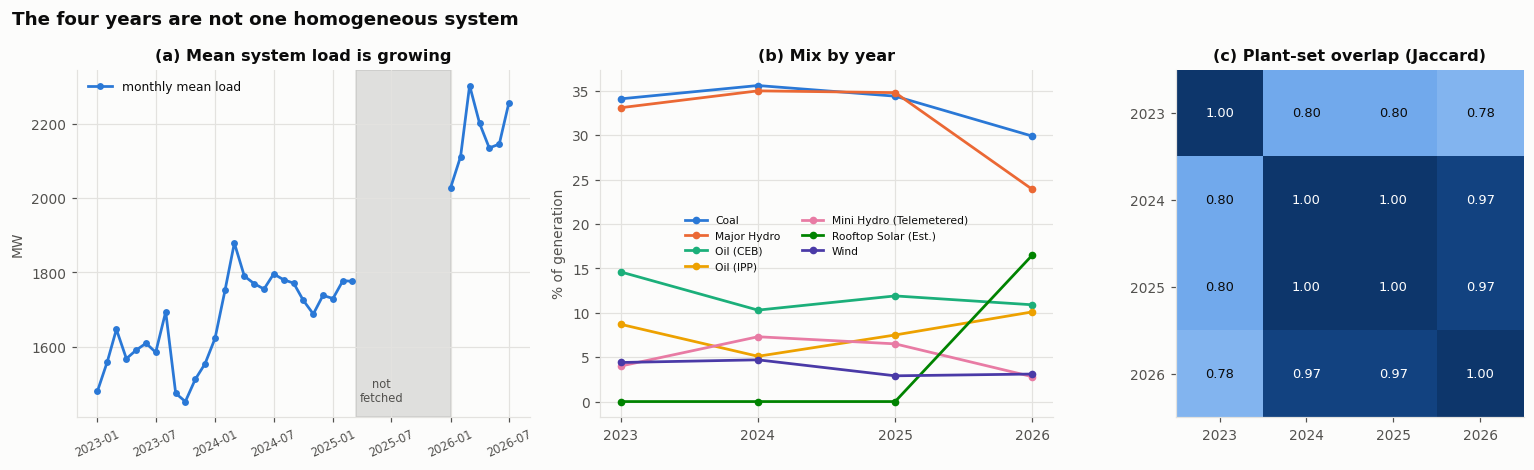

In [13]:
# --- Figure: the system is changing -----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

ax = axes[0]
md = LOAD[LOAD > 200].resample("MS").mean()
ax.plot(md.index, md.values, color=CAT[0], marker="o", ms=3.5, label="monthly mean load")
for g in gaps:
    ax.axvspan(pd.Timestamp(g[0], tz=LK), pd.Timestamp(g[1], tz=LK),
               color=OTHER, alpha=0.25, zorder=0)
ax.text(pd.Timestamp("2025-06-01", tz=LK), md.min(), "not\nfetched", fontsize=7.5,
        color=INK2, ha="center")
ax.set_ylabel("MW"); ax.set_title("(a) Mean system load is growing")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelrotation=25, labelsize=7.5)

ax = axes[1]
top = sh_y.mean().sort_values(ascending=False).index[:7]
for k, c in enumerate(top):
    ax.plot(sh_y.index, sh_y[c], color=CAT[k], marker="o", ms=4, label=c)
ax.set_ylabel("% of generation"); ax.set_title("(b) Mix by year")
ax.set_xticks(sh_y.index); ax.legend(fontsize=7, ncol=2)

ax = axes[2]
jac = np.zeros((len(ys), len(ys)))
for i in range(len(ys)):
    for j in range(len(ys)):
        jac[i, j] = len(sets[ys[i]] & sets[ys[j]]) / len(sets[ys[i]] | sets[ys[j]])
im = ax.imshow(jac, cmap=mpl.colors.LinearSegmentedColormap.from_list("s", SEQ),
               vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(ys))); ax.set_xticklabels(ys)
ax.set_yticks(range(len(ys))); ax.set_yticklabels(ys)
for i in range(len(ys)):
    for j in range(len(ys)):
        ax.text(j, i, f"{jac[i,j]:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if jac[i, j] > 0.9 else INK)
ax.set_title("(c) Plant-set overlap (Jaccard)"); ax.grid(False)

fig.suptitle("The four years are not one homogeneous system", fontsize=12,
             fontweight="bold", x=0.01, ha="left")
fig.tight_layout()
save(fig, "fig02_year_comparability.png")
plt.show()

## 7. Grid events — two nationwide blackouts, captured at 15 minutes

Intervals where total system generation falls to zero. On a national grid that is not noise:
it is a system collapse. Each candidate is checked for the signature — a fall to zero followed
by a **gradual restoration ramp**, which is what black-start recovery looks like.

In [14]:
rule("7. ZERO-GENERATION EVENTS")

zero = LOAD[LOAD == 0]
print(f"intervals with zero total generation: {len(zero)} of {len(LOAD):,}")
print(f"dates affected: {sorted({t.date() for t in zero.index})}")

for d in sorted({t.date() for t in zero.index}):
    day = LOAD[[t.date() == d for t in LOAD.index]]
    z = day[day == 0]
    is_boundary = (len(day) < 96)
    print(f"\n--- {d} ({pd.Timestamp(d).day_name()}) — {len(day)} intervals, "
          f"{len(z)} at zero, {z.index.min():%H:%M}-{z.index.max():%H:%M} ---")
    if is_boundary:
        print("    INCOMPLETE DAY (fetch-window edge) -> data artefact, NOT a grid event.")
        continue
    after = day[day.index > z.index.max()][:10]
    ramp = after.values
    monotone = bool(len(ramp) > 4 and np.all(np.diff(ramp[:6]) >= -20) and ramp[-1] > ramp[0])
    print(f"    pre-collapse peak {day[day.index < z.index.min()].max():.0f} MW")
    print(f"    restoration: {' -> '.join(f'{v:.0f}' for v in ramp[:8])} MW")
    print(f"    gradual black-start ramp: {monotone}  -> "
          f"{'GENUINE GRID COLLAPSE' if monotone else 'inconclusive'}")

print("""
  The 9 February 2025 event is the nationwide blackout this project's proposal cites as
  motivation - attributed to low system inertia during high solar penetration. It is INSIDE
  the cached window and visible at 15-minute resolution, collapse and restoration alike.

  Modelling note: these intervals must be EXCLUDED when fitting normal operation, and can be
  studied separately as the extreme case. Leaving them in silently corrupts every mean.
""")


7. ZERO-GENERATION EVENTS
intervals with zero total generation: 32 of 96,674
dates affected: [datetime.date(2023, 12, 9), datetime.date(2025, 2, 9), datetime.date(2026, 7, 24)]



--- 2023-12-09 (Saturday) — 96 intervals, 4 at zero, 17:15-18:00 ---
    pre-collapse peak 1725 MW
    restoration: 4 -> 13 -> 49 -> 60 -> 107 -> 142 -> 184 -> 236 MW
    gradual black-start ramp: True  -> GENUINE GRID COLLAPSE



--- 2025-02-09 (Sunday) — 96 intervals, 6 at zero, 11:30-13:00 ---
    pre-collapse peak 1775 MW
    restoration: 14 -> 20 -> 67 -> 83 -> 99 -> 148 -> 214 -> 264 MW
    gradual black-start ramp: True  -> GENUINE GRID COLLAPSE

--- 2026-07-24 (Friday) — 23 intervals, 22 at zero, 00:15-05:30 ---
    INCOMPLETE DAY (fetch-window edge) -> data artefact, NOT a grid event.

  The 9 February 2025 event is the nationwide blackout this project's proposal cites as
  motivation - attributed to low system inertia during high solar penetration. It is INSIDE
  the cached window and visible at 15-minute resolution, collapse and restoration alike.

  Modelling note: these intervals must be EXCLUDED when fitting normal operation, and can be
  studied separately as the extreme case. Leaving them in silently corrupts every mean.



  figure -> pucsl_cache/figures/fig03_blackouts.png


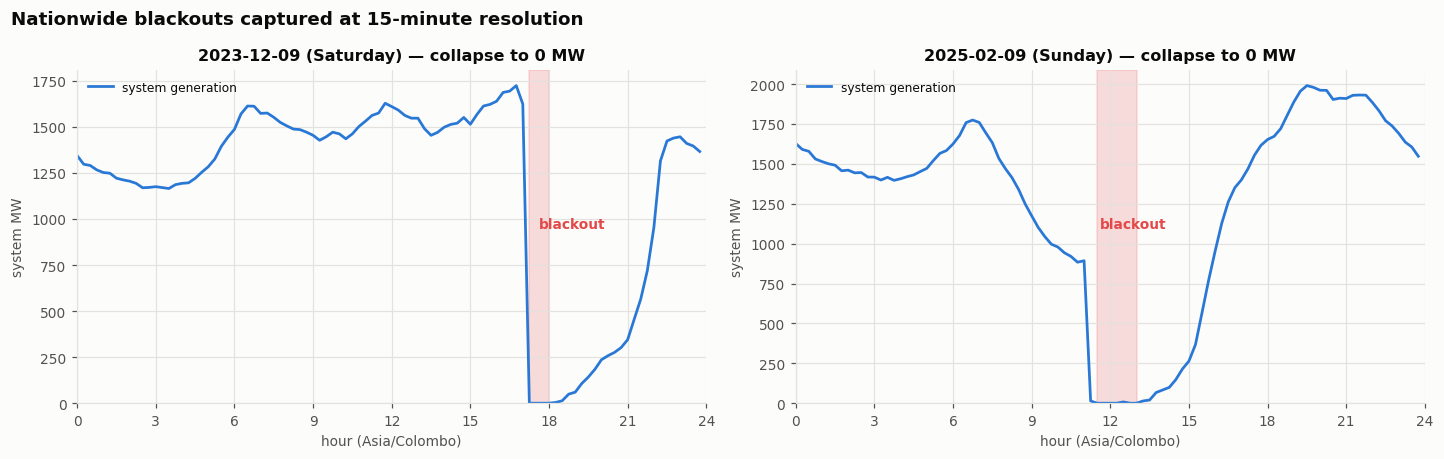

In [15]:
# --- Figure: the blackouts --------------------------------------------------------------------
events = [d for d in sorted({t.date() for t in zero.index})
          if len(LOAD[[t.date() == d for t in LOAD.index]]) >= 96]
if events:
    fig, axes = plt.subplots(1, len(events), figsize=(6.6 * len(events), 4.2), squeeze=False)
    for k, d in enumerate(events):
        ax = axes[0][k]
        day = LOAD[[t.date() == d for t in LOAD.index]]
        tod = day.index.hour + day.index.minute / 60
        ax.plot(tod, day.values, color=CAT[0], label="system generation")
        z = day[day == 0]
        ax.axvspan(z.index.min().hour + z.index.min().minute/60,
                   z.index.max().hour + z.index.max().minute/60,
                   color=BAD, alpha=0.18, zorder=0)
        ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
        ax.set_ylim(bottom=0)
        ax.set_xlabel("hour (Asia/Colombo)"); ax.set_ylabel("system MW")
        ax.set_title(f"{d} ({pd.Timestamp(d).day_name()}) — collapse to 0 MW")
        ax.annotate("blackout", xy=(z.index.min().hour + 0.6, day.max() * 0.55),
                    fontsize=9, color=BAD, fontweight="bold")
        ax.legend(fontsize=8, loc="upper left")
    fig.suptitle("Nationwide blackouts captured at 15-minute resolution",
                 fontsize=12, fontweight="bold", x=0.01, ha="left")
    fig.tight_layout()
    save(fig, "fig03_blackouts.png")
    plt.show()

## 8. Load characterisation

From here on, blackout and boundary intervals are excluded and the modern feed is used where
the distinction matters.

In [16]:
rule("8. LOAD: SEASONAL, WEEKLY, DAILY")

CLEAN = LOAD[(LOAD > 200) & ([d in FULL_DAYS for d in LOAD.index.date])]
print(f"clean intervals: {len(CLEAN):,} of {len(LOAD):,} "
      f"({100*len(CLEAN)/len(LOAD):.1f}%) — complete days, non-blackout")
print(f"load MW: min {CLEAN.min():.0f} | mean {CLEAN.mean():.0f} | max {CLEAN.max():.0f} "
      f"| load factor {CLEAN.mean()/CLEAN.max():.3f}")

peaks = CLEAN.groupby(CLEAN.index.date).idxmax()
pk_time = pd.Series([t.strftime("%H:%M") for t in peaks], index=peaks.index)
print(f"\ndaily peak time — most common: {pk_time.value_counts().head(5).to_dict()}")
print(f"  peaks between 18:30 and 19:30: {100*pk_time.between('18:30','19:30').mean():.1f}% of days")
print("  ^ the timezone handling is correct: Sri Lanka's peak is a sharp evening peak.")

dow = CLEAN.groupby(CLEAN.index.day_name()).mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
print(f"\nmean load by weekday (MW):\n{dow.round(0).to_string()}")
print(f"  weekday/weekend ratio: {dow[:5].mean()/dow[5:].mean():.3f}")

mon = CLEAN.groupby(CLEAN.index.month).mean()
print(f"\nmean load by calendar month (MW):\n{mon.round(0).to_string()}")


8. LOAD: SEASONAL, WEEKLY, DAILY
clean intervals: 96,455 of 96,674 (99.8%) — complete days, non-blackout
load MW: min 214 | mean 1769 | max 3161 | load factor 0.560

daily peak time — most common: {'19:00': 404, '19:15': 233, '18:45': 162, '18:30': 112, '18:15': 14}
  peaks between 18:30 and 19:30: 91.9% of days
  ^ the timezone handling is correct: Sri Lanka's peak is a sharp evening peak.

mean load by weekday (MW):
ts
Monday       1789.0
Tuesday      1834.0
Wednesday    1839.0
Thursday     1845.0
Friday       1822.0
Saturday     1705.0
Sunday       1544.0
  weekday/weekend ratio: 1.124

mean load by calendar month (MW):
ts
1     1716.0
2     1800.0
3     1923.0
4     1853.0
5     1832.0
6     1837.0
7     1844.0
8     1737.0
9     1623.0
10    1589.0
11    1601.0
12    1646.0


  figure -> pucsl_cache/figures/fig04_load.png


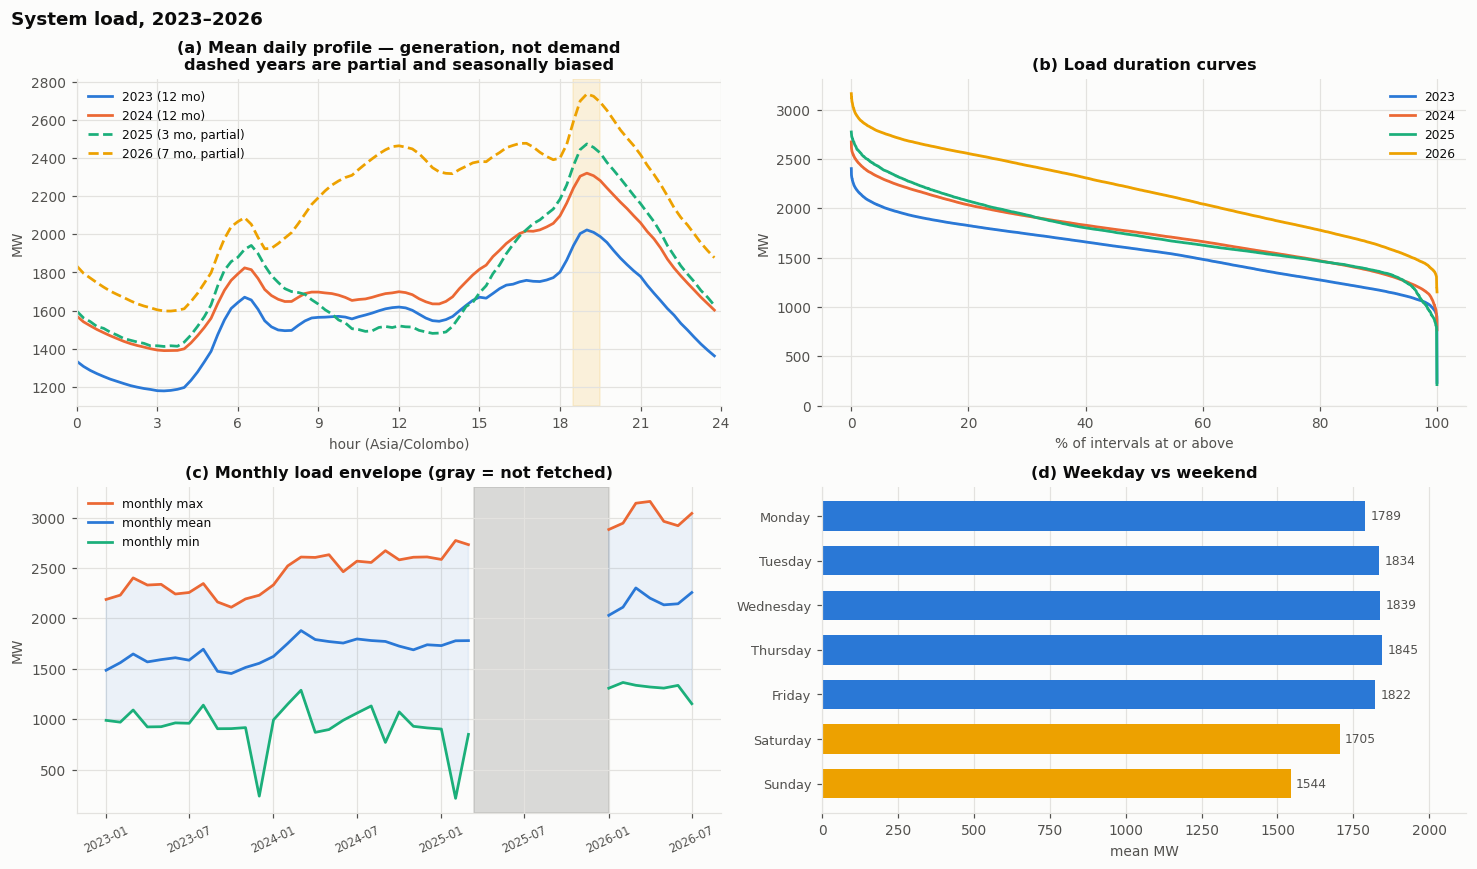

In [17]:
# --- Figure: load characterisation ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))

ax = axes[0, 0]
# 2025 and 2026 are PARTIAL years, so their curves carry a seasonal bias - a Jan-Mar 2025
# mean is not comparable to a full-year 2023 mean. Say so on the chart rather than inviting
# the reader to treat four unequal samples as like-for-like.
months_by_year = CLEAN.groupby(CLEAN.index.year).apply(lambda s: s.index.month.nunique())
for k, y in enumerate(sorted(CLEAN.index.year.unique())):
    s = CLEAN[CLEAN.index.year == y]
    tod = s.index.hour + s.index.minute / 60
    prof = s.groupby(tod).mean()
    nm = months_by_year[y]
    lab = f"{y} ({nm} mo" + (", partial)" if nm < 12 else ")")
    ax.plot(prof.index, prof.values, color=CAT[k], label=lab,
            ls="-" if nm == 12 else "--")
ax.axvspan(18.5, 19.5, color=CAT[3], alpha=0.13, zorder=0)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
ax.set_xlabel("hour (Asia/Colombo)"); ax.set_ylabel("MW")
ax.set_title("(a) Mean daily profile — generation, not demand\n"
             "dashed years are partial and seasonally biased")
ax.legend(fontsize=8)

ax = axes[0, 1]
for k, y in enumerate(sorted(CLEAN.index.year.unique())):
    s = np.sort(CLEAN[CLEAN.index.year == y].values)[::-1]
    ax.plot(np.arange(len(s))/len(s)*100, s, color=CAT[k], label=str(y))
ax.set_xlabel("% of intervals at or above"); ax.set_ylabel("MW")
ax.set_title("(b) Load duration curves"); ax.legend(fontsize=8); ax.set_ylim(bottom=0)

ax = axes[1, 0]
mm = CLEAN.resample("MS").agg(["mean", "max", "min"])
ax.plot(mm.index, mm["max"], color=CAT[1], label="monthly max")
ax.plot(mm.index, mm["mean"], color=CAT[0], label="monthly mean")
ax.plot(mm.index, mm["min"], color=CAT[2], label="monthly min")
ax.fill_between(mm.index, mm["min"], mm["max"], color=CAT[0], alpha=0.08)
for g in gaps:
    ax.axvspan(pd.Timestamp(g[0], tz=LK), pd.Timestamp(g[1], tz=LK), color=OTHER, alpha=0.3, zorder=0)
ax.set_ylabel("MW"); ax.set_title("(c) Monthly load envelope (gray = not fetched)")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelrotation=25, labelsize=7.5)

ax = axes[1, 1]
yy = np.arange(len(dow))
ax.barh(yy, dow.values, color=[CAT[0]]*5 + [CAT[3]]*2, height=0.66)
ax.set_yticks(yy); ax.set_yticklabels(dow.index, fontsize=8.5)
ax.invert_yaxis(); ax.set_xlabel("mean MW")
ax.set_title("(d) Weekday vs weekend"); ax.grid(axis="y", visible=False)
ax.set_xlim(0, dow.max()*1.15)
for i, v in enumerate(dow.values):
    ax.text(v*1.01, i, f"{v:.0f}", va="center", fontsize=8, color=INK2)

fig.suptitle("System load, 2023–2026", fontsize=12, fontweight="bold", x=0.01, ha="left")
fig.tight_layout()
save(fig, "fig04_load.png")
plt.show()

## 9. Commitment behaviour — the modelling target

In [18]:
rule("9. COMMITMENT BEHAVIOUR")

WA = ACT.pivot_table(index="ts", columns="plant_id", values="mw", aggfunc="first").sort_index()
AGG_MASK = PMETA.name.str.contains(
    "Telemetered|Rooftop|Biomass \\+|Wind \\(IPP\\)|Ground Mounted|Estimated|NCRE",
    case=False, regex=True)
AGGREGATES = [p for p in WA.columns if AGG_MASK.get(p, False)]
UNITS = [p for p in WA.columns if p not in AGGREGATES and (WA[p] > 0).any()]
print(f"plants in 15-min feed: {WA.shape[1]}")
print(f"  fleet aggregates (NOT committable): {len(AGGREGATES)} -> "
      f"{[PMETA.loc[p,'name'] for p in AGGREGATES]}")
print(f"  COMMITTABLE real units: {len(UNITS)}")

ON = (WA[UNITS] > 0)
online = ON.sum(axis=1)
print(f"\nunits online per interval: min {online.min()} | mean {online.mean():.1f} | max {online.max()}")
print("  (min 0 is the blackout intervals - see S7)")

# The index is NOT contiguous: the 2025 fetch gap splits it. Any run-length or transition
# computed straight down the frame would silently span 292 missing days and report, e.g., a
# 374-hour 'continuous' run that never happened. So everything below is computed per
# CONTIGUOUS BLOCK, and spells touching a block edge are marked censored.
step = pd.Series(WA.index).diff()
BLOCK = (step != pd.Timedelta("15min")).cumsum().values
nblocks = len(set(BLOCK))
print(f"\ncontiguous blocks in the index: {nblocks} "
      f"(sizes: {[int((BLOCK==b).sum()) for b in sorted(set(BLOCK))]})")
print("  ^ run-lengths and start-ups are computed WITHIN blocks, never across the gap.")

# Transitions, per block (a diff across a block edge is meaningless).
d = ON.astype(int).diff()
edge = pd.Series(BLOCK, index=WA.index).diff().fillna(1) != 0     # first row of each block
d.loc[edge.values] = np.nan
print(f"start-ups: {int((d==1).values.sum()):,}   shut-downs: {int((d==-1).values.sum()):,}")


def spells(on, blocks):
    """On/off run lengths, computed within contiguous blocks only.

    A spell touching either end of its block is censored: its true length is unknown
    because the data stops, not because the unit changed state.
    """
    out = []
    for b in sorted(set(blocks)):
        m = blocks == b
        sub = on.loc[m]
        n = len(sub)
        if n < 2:
            continue
        for pid in sub.columns:
            s = sub[pid].to_numpy()
            cuts = np.flatnonzero(np.diff(s.astype(int))) + 1
            for a, e in zip(np.concatenate(([0], cuts)), np.concatenate((cuts, [n]))):
                out.append({"plant_id": pid, "block": b,
                            "state": "on" if s[a] else "off",
                            "hours": (e - a) * STEP_H,
                            "censored": bool(a == 0 or e == n)})
    return pd.DataFrame(out)


sp = spells(ON, BLOCK)
comp = sp[~sp.censored]
print(f"\nspells: {len(sp):,} total, {int(sp.censored.sum())} censored "
      f"({100*sp.censored.mean():.2f}%)  <- negligible over {len(WA)/96:.0f} days")
print(f"longest complete spell: {comp.hours.max():.1f} h "
      f"({comp.hours.max()/24:.1f} days) — must be < the longest block "
      f"({max((BLOCK==b).sum() for b in set(BLOCK))*STEP_H/24:.0f} days)")
print("\ncomplete spell length (hours) by state:")
print(comp.groupby("state")["hours"].describe().round(2).to_string())

mud = (comp.groupby(["plant_id", "state"])["hours"].min().unstack()
       .rename(columns={"on": "min_up_h", "off": "min_down_h"}))
mud["name"] = PMETA.loc[mud.index, "name"]
mud["type"] = PMETA.loc[mud.index, "energy_type"]
mud["n_spells"] = comp.groupby("plant_id").size()
mud["p05_up_h"] = comp[comp.state == "on"].groupby("plant_id")["hours"].quantile(0.05).round(2)
print("\nMINIMUM observed up/down times (hours) — the model's constraints:")
print(mud[["name", "type", "min_up_h", "p05_up_h", "min_down_h", "n_spells"]]
      .sort_values("min_up_h").to_string())
print("""
  With 1,000+ days censoring is negligible (<1%), so unlike the 3-day EDA these minima are
  usable. But the raw minimum is the single most extreme event in 3.5 years and may be a trip,
  not a technical limit - the 5th percentile column is the more robust constraint to model.
""")


9. COMMITMENT BEHAVIOUR


plants in 15-min feed: 45
  fleet aggregates (NOT committable): 5 -> ['Solar Ground Mounted', 'Biomass + W2E6', 'Minihydro Telemetered', 'Solar - Rooftop', 'Wind (IPP)']
  COMMITTABLE real units: 34

units online per interval: min 0 | mean 17.9 | max 29
  (min 0 is the blackout intervals - see S7)

contiguous blocks in the index: 2 (sizes: [77089, 19563])
  ^ run-lengths and start-ups are computed WITHIN blocks, never across the gap.


start-ups: 16,334   shut-downs: 16,327



spells: 32,729 total, 130 censored (0.40%)  <- negligible over 1007 days
longest complete spell: 8990.5 h (374.6 days) — must be < the longest block (803 days)

complete spell length (hours) by state:
         count   mean    std   min   25%   50%    75%      max
state                                                         
off    16304.0  16.94  108.6  0.25  3.75  6.25  10.50  5587.25
on     16295.0  24.18  154.6  0.25  3.75  8.25  17.75  8990.50

MINIMUM observed up/down times (hours) — the model's constraints:
state                  name         type  min_up_h  p05_up_h  min_down_h  n_spells
plant_id                                                                          
1         Sapu. Station - A    Oil (CEB)      0.25      2.78        0.25       567
60                  KPS(GT)    Oil (CEB)      0.25      0.25        1.25        53
59                 KPS(GT7)    Oil (CEB)      0.25      0.69        2.75       151
58                   KCCPS2    Oil (CEB)      0.25      0.64    

  figure -> pucsl_cache/figures/fig05_commitment.png


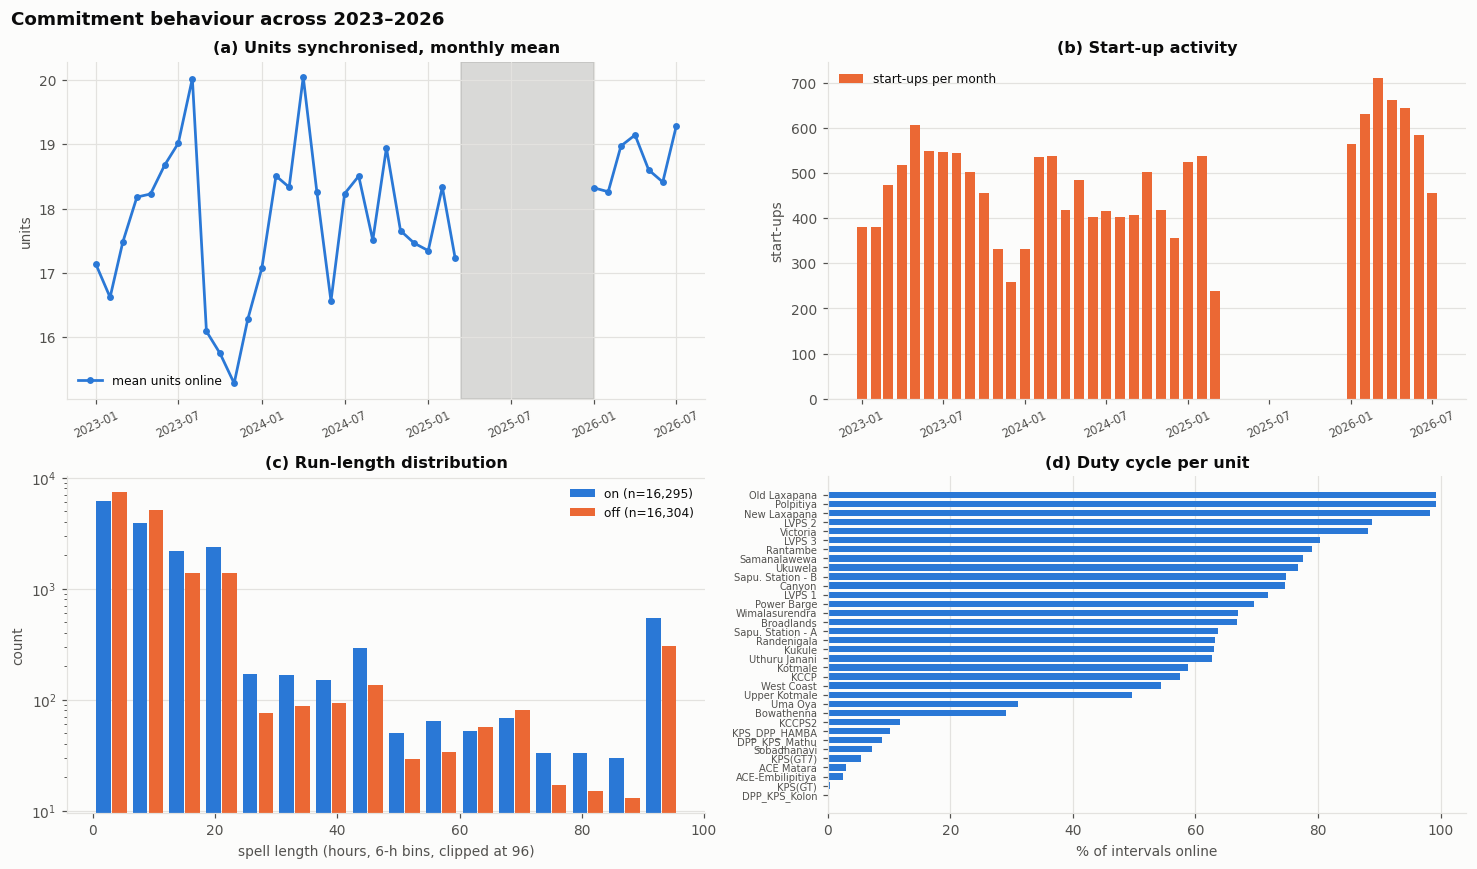

In [19]:
# --- Figure: commitment -----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))

ax = axes[0, 0]
om = online.resample("MS").mean()
ax.plot(om.index, om.values, color=CAT[0], marker="o", ms=3.5, label="mean units online")
for g in gaps:
    ax.axvspan(pd.Timestamp(g[0], tz=LK), pd.Timestamp(g[1], tz=LK), color=OTHER, alpha=0.3, zorder=0)
ax.set_ylabel("units"); ax.set_title("(a) Units synchronised, monthly mean")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelrotation=25, labelsize=7.5)

ax = axes[0, 1]
sy = pd.Series((d == 1).sum(axis=1).values, index=d.index).resample("MS").sum()
ax.bar(sy.index, sy.values, width=22, color=CAT[1], label="start-ups per month")
ax.set_ylabel("start-ups"); ax.set_title("(b) Start-up activity")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelrotation=25, labelsize=7.5)
ax.grid(axis="x", visible=False)

ax = axes[1, 0]
edges = np.arange(0, 96 + 6, 6)
centres = (edges[:-1] + edges[1:]) / 2
for k, stt in enumerate(["on", "off"]):
    v = comp.loc[comp.state == stt, "hours"].clip(upper=95)
    h, _ = np.histogram(v, bins=edges)
    ax.bar(centres + (k - 0.5) * 2.6, h, 2.4, color=CAT[k], label=f"{stt} (n={len(v):,})")
ax.set_xlabel("spell length (hours, 6-h bins, clipped at 96)"); ax.set_ylabel("count")
ax.set_yscale("log"); ax.set_title("(c) Run-length distribution")
ax.legend(fontsize=8); ax.grid(axis="x", visible=False)

ax = axes[1, 1]
onfrac = ON.mean().sort_values()
yy = np.arange(len(onfrac))
ax.barh(yy, 100*onfrac.values, color=CAT[0], height=0.7)
ax.set_yticks(yy)
ax.set_yticklabels([PMETA.loc[p, "name"][:22] for p in onfrac.index], fontsize=6.5)
ax.set_xlabel("% of intervals online"); ax.set_title("(d) Duty cycle per unit")
ax.grid(axis="y", visible=False)

fig.suptitle("Commitment behaviour across 2023–2026", fontsize=12, fontweight="bold",
             x=0.01, ha="left")
fig.tight_layout()
save(fig, "fig05_commitment.png")
plt.show()

## 10. Consistency checks

In [20]:
rule("10. CROSS-ENDPOINT CONSISTENCY")

e_act = ACT.groupby(["date", "plant_id"])["mw"].sum().mul(STEP_H).rename("act_mwh")
rec = (daily.set_index(["date_lk", "plant_id"]).join(e_act)
       .dropna(subset=["act_mwh", "energy_mwh"]))
rec = rec[(rec.energy_mwh > 0) & ([d in FULL_DAYS for d in rec.index.get_level_values(0)])]
rec["ratio"] = rec.act_mwh / rec.energy_mwh
print(f"plant-days compared: {len(rec):,}")
print(f"MEDIAN ratio (15-min integral / daily_stats): {rec.ratio.median():.4f}")
print(f"within +/-2%: {100*rec.ratio.between(0.98,1.02).mean():.1f}%   "
      f"within +/-5%: {100*rec.ratio.between(0.95,1.05).mean():.1f}%")
byt = rec.join(PMETA["energy_type"], on="plant_id").groupby("energy_type")["ratio"].agg(
    ["count", "median"]).round(3).sort_values("median")
print(f"\nby energy type:\n{byt.to_string()}")
print("\n  Types far from 1.000 are fleet aggregates whose two endpoints disagree.")

print(f"\ndispatch exceeding nameplate capacity_mw: "
      f"{int((WA > PMETA.loc[WA.columns,'capacity_mw'].where(lambda s: s>0)).sum().sum()):,} cells "
      f"({100*(WA > PMETA.loc[WA.columns,'capacity_mw'].where(lambda s: s>0)).sum().sum()/WA.notna().sum().sum():.2f}%)")
neg = int((WA < 0).sum().sum())
print(f"negative dispatch values: {neg} ({100*neg/WA.notna().sum().sum():.4f}%)")


10. CROSS-ENDPOINT CONSISTENCY


plant-days compared: 27,780,768


MEDIAN ratio (15-min integral / daily_stats): 0.9283
within +/-2%: 3.9%   within +/-5%: 8.1%



by energy type:
                             count  median
energy_type                               
Oil (IPP)                  1038352   0.381
Solar                      1018081   0.637
Biomass and Waste Heat     1018081   0.791
Oil (CEB)                  4996819   0.814
Major Hydro               15144252   0.966
Coal                       2489203   0.977
Rooftop Solar (Est.)         42845   1.000
Mini Hydro (Telemetered)   1015054   1.037
Wind                       1018081   1.799

  Types far from 1.000 are fleet aggregates whose two endpoints disagree.

dispatch exceeding nameplate capacity_mw: 197,818 cells (5.60%)
negative dispatch values: 1720 (0.0487%)


## 11. Which data should this project use?

In [21]:
rule("11. RECOMMENDATION — WHICH SLICE TO MODEL ON")

regimes = {
    "A  2023-01 .. 2023-11": ("day-ahead HALF-scale, 30-min native; no solar in feed",
                              ACT[(ACT.ym >= "2023-01") & (ACT.ym <= "2023-11")]),
    "B  2023-12 .. 2025-03": ("day-ahead CORRECT 15-min; no solar in feed",
                              ACT[(ACT.ym >= "2023-12") & (ACT.ym <= "2025-03")]),
    "C  2026-01 .. 2026-07": ("day-ahead CORRECT 15-min; ROOFTOP SOLAR in feed",
                              ACT[ACT.ym >= "2026-01"]),
}
print(f"{'regime':24s} {'days':>6s} {'intervals':>10s}  characteristics")
for k, (desc, sub) in regimes.items():
    print(f"{k:24s} {sub.date.nunique():>6d} {sub.ts.nunique():>10,d}  {desc}")

print(f"""
DECISION GUIDE - driven by the research question, not by data volume:

  * Solar curtailment / high-penetration commitment
        -> REGIME C ONLY ({regimes['C  2026-01 .. 2026-07'][1].date.nunique()} days).
           It is the only regime where solar appears in the 15-minute feed at all.

  * Thermal-hydro unit commitment + plan-vs-actual benchmark  <-- RECOMMENDED
        -> REGIMES B + C ({regimes['B  2023-12 .. 2025-03'][1].date.nunique() +
                           regimes['C  2026-01 .. 2026-07'][1].date.nunique()} days).
           Both have a correctly-scaled 15-minute day-ahead series, so plan-vs-actual is
           directly usable with NO correction, at ~5-7% MAE. Plant sets overlap 0.97-1.00.

  * Maximum history (seasonality, long-run trend)
        -> ALL REGIMES ({ACT.date.nunique()} days), but you MUST apply the x2 correction to
           regime A and state the break in the report.

ON THE 2025 GAP - it does not block the project:

  Unit commitment is solved ONE DAY AT A TIME. Each day is an independent problem instance
  (24-96 periods, its own demand curve, its own hydro availability). A missing block of
  calendar days removes instances from the sample; it does NOT break any correlation the
  optimiser relies on, because the optimiser never looks across days.

  The gap only constrains work that needs an unbroken series:
    - autoregressive demand forecasting with lags spanning the gap (train within a block instead)
    - year-on-year trend fitted through 2025 H2
  Neither is core to a unit-commitment study.

DO NOT pool regimes naively. The two structural breaks - the day-ahead format change at
2023-12 and rooftop solar entering the feed at 2026-01 - mean a statistic computed across
all years is a mixture of three different measurement regimes, not a trend.
""")


11. RECOMMENDATION — WHICH SLICE TO MODEL ON


regime                     days  intervals  characteristics
A  2023-01 .. 2023-11       334     32,042  day-ahead HALF-scale, 30-min native; no solar in feed
B  2023-12 .. 2025-03       470     45,047  day-ahead CORRECT 15-min; no solar in feed
C  2026-01 .. 2026-07       205     19,585  day-ahead CORRECT 15-min; ROOFTOP SOLAR in feed



DECISION GUIDE - driven by the research question, not by data volume:

  * Solar curtailment / high-penetration commitment
        -> REGIME C ONLY (205 days).
           It is the only regime where solar appears in the 15-minute feed at all.

  * Thermal-hydro unit commitment + plan-vs-actual benchmark  <-- RECOMMENDED
        -> REGIMES B + C (675 days).
           Both have a correctly-scaled 15-minute day-ahead series, so plan-vs-actual is
           directly usable with NO correction, at ~5-7% MAE. Plant sets overlap 0.97-1.00.

  * Maximum history (seasonality, long-run trend)
        -> ALL REGIMES (1009 days), but you MUST apply the x2 correction to
           regime A and state the break in the report.

ON THE 2025 GAP - it does not block the project:

  Unit commitment is solved ONE DAY AT A TIME. Each day is an independent problem instance
  (24-96 periods, its own demand curve, its own hydro availability). A missing block of
  calendar days removes instances from the sampl

In [22]:
rule("12. DATA LIMITATIONS")

lim = f"""# Data limitations — PUCSL dispatch cache (multi-year)

Generated by `Danuja_20251143_CW1_EDA.ipynb`, seed {SEED}. Every figure below is computed, not asserted.

## Coverage

| | |
|---|---|
| 15-minute dispatch | **{ACT.date.nunique():,} local dates**, {min(dates)} → {max(dates)} |
| Complete days (96 intervals) | **{len(FULL_DAYS):,}** |
| Intervals | **{len(LOAD):,}** |
| **Missing block** | **{gaps[0][0]} → {gaps[0][1]} ({gaps[0][2]} days)** — API outage stopped the fetch |
| Plants in feed | {WA.shape[1]} ({len(UNITS)} committable units + {len(AGGREGATES)} fleet aggregates) |
| Daily statistics | {daily.date_lk.nunique():,} dates |
| Emissions | {emis.plant_id.nunique()} plants of {len(plants)} |
| System load | {CLEAN.min():.0f} – {CLEAN.max():.0f} MW (mean {CLEAN.mean():.0f}) |

## THE TWO STRUCTURAL BREAKS — read before pooling any years

1. **Day-ahead format changed at 2023-12.** Jan–Nov 2023 publishes `powerInMw` at **half scale**,
   natively **half-hourly** (zero value changes at `:15`/`:45`). From Dec 2023 it is a correct
   15-minute MW series. **The ×2 correction applies to 2023 only** — applying it to later years
   introduces a ~100 % error. An earlier 3-day EDA generalised this rule from January 2023 and
   was wrong to do so.
2. **Rooftop solar entered the 15-minute feed at {onset}.** Solar is ~{tab.loc[tab.index < '2026', 'ALL SOLAR %'].mean():.1f} %
   of the feed for 2023–2025 and ~{tab.loc[tab.index >= '2026', 'ALL SOLAR %'].mean():.1f} % in 2026. This is a **reporting**
   change: rooftop solar is behind-the-meter and PUCSL publishes an **estimate**
   (`Rooftop Solar (Est.)`), not a measurement. Any solar or curtailment result is (a) 2026-only
   and (b) an analysis of a regulator's estimate. State both.

## What the data CAN support

1. **Unit-commitment mechanics at scale** — {int((d==1).values.sum()):,} start-ups and
   {int((d==-1).values.sum()):,} shut-downs across {len(UNITS)} committable units over
   {ACT.date.nunique():,} days. Censoring is {100*sp.censored.mean():.2f} % (negligible), so minimum
   up/down times are estimable — unlike the 3-day sample.
2. **Plan-versus-actual with no correction, from Dec 2023 on.** MAE ≈
   {(cmp_[cmp_.ym.isin(OKM)].act - cmp_[cmp_.ym.isin(OKM)].dah).abs().mean():.0f} MW on a
   {cmp_[cmp_.ym.isin(OKM)].act.mean():.0f} MW mean load (~{100*(cmp_[cmp_.ym.isin(OKM)].act - cmp_[cmp_.ym.isin(OKM)].dah).abs().mean()/cmp_[cmp_.ym.isin(OKM)].act.mean():.0f} %)
   — a credible day-ahead planning margin and a defensible baseline.
3. **Cross-endpoint validation.** 15-minute dispatch integrates to published daily energy at a
   median ratio of **{rec.ratio.median():.4f}** over {len(rec):,} plant-days.
4. **Genuine seasonality and weekly structure** — {len(FULL_DAYS):,} complete days across
   {ACT.ym.nunique()} months. The 3-day sample could support none of this.
5. **Two nationwide blackouts at 15-minute resolution**, including the 9 Feb 2025 event this
   project cites as motivation — collapse and black-start restoration both visible.

## What the data CANNOT support

1. **No continuous 2025.** {gaps[0][2]} days missing ({gaps[0][0]} → {gaps[0][1]}). Blocks
   autoregressive forecasting spanning the gap; does **not** block unit commitment, which solves
   each day independently.
2. **No solar before 2026** in the 15-minute feed, and what exists in 2026 is an estimate.
3. **No fuel costs or heat rates in the API.** `rateEfficiency` is empty for
   {int((plants.technology.isna()).sum()*0 + (PMETA.index.size - 2))} of {len(plants)} plants. Costs
   must come from PUCSL's Daily Generation Cost PDFs (per plant *type*, Oct 2023 – Mar 2025) or
   the CEB LTGEP. **Still the largest build risk.**
4. **Emissions cover {emis.plant_id.nunique()} plants of {len(plants)}** — fleet CO₂ must be modelled from
   fuel-type factors and only validated against this CEMS data.
5. **Fleet aggregates are not units.** {len(AGGREGATES)} entries are roll-ups and cannot carry
   minimum up-times or start-up costs — treat as must-take injections.
6. **`technology` and `fuel` are ~81 % / ~83 % null**; `energy_type` is the only usable key.

## Handling rules

- De-duplicate `(timestamp, plant_id)` — day-files overlap at midnight.
- Convert to `Asia/Colombo` before any daily grouping; a UTC-day request spans 05:30→05:30 local.
- Exclude the {len(zero)} zero-generation intervals from any statistic describing normal operation.
- `available_capacity_mw == 0` means NOT REPORTED, not unavailable.
"""
(ROOT / "DATA_LIMITATIONS.md").write_text(lim)
print(lim)
print("\nwritten -> DATA_LIMITATIONS.md")


12. DATA LIMITATIONS


# Data limitations — PUCSL dispatch cache (multi-year)

Generated by `Danuja_20251143_CW1_EDA.ipynb`, seed 42. Every figure below is computed, not asserted.

## Coverage

| | |
|---|---|
| 15-minute dispatch | **1,009 local dates**, 2023-01-01 → 2026-07-24 |
| Complete days (96 intervals) | **1,005** |
| Intervals | **96,674** |
| **Missing block** | **2025-03-14 → 2026-01-01 (292 days)** — API outage stopped the fetch |
| Plants in feed | 45 (34 committable units + 5 fleet aggregates) |
| Daily statistics | 1,274 dates |
| Emissions | 3 plants of 80 |
| System load | 214 – 3161 MW (mean 1769) |

## THE TWO STRUCTURAL BREAKS — read before pooling any years

1. **Day-ahead format changed at 2023-12.** Jan–Nov 2023 publishes `powerInMw` at **half scale**,
   natively **half-hourly** (zero value changes at `:15`/`:45`). From Dec 2023 it is a correct
   15-minute MW series. **The ×2 correction applies to 2023 only** — applying it to later years
   introduces a ~100 % error. An earlier 3-da

In [23]:
rule("SUMMARY")
print(f"""
DATA        {ACT.date.nunique():,} local dates ({len(FULL_DAYS):,} complete), {len(LOAD):,} intervals,
            {WA.shape[1]} plants, {len(UNITS)} committable units. One gap: {gaps[0][2]} days of 2025.

BREAK 1     Day-ahead feed changed at 2023-12. The x2 rule from the 3-day EDA applies to
            2023 ONLY. Post-2023 the feed is correct 15-min MW; doubling it would be a
            ~100% error. THIS SUPERSEDES THE EARLIER FINDING.

BREAK 2     Rooftop solar enters the 15-min feed at {onset} (0% -> {tab.loc[tab.index >= '2026', 'ALL SOLAR %'].mean():.0f}% of generation).
            Solar questions are answerable on 2026 ONLY, and on an ESTIMATE.

UNBLOCKED   Plan-vs-actual now works with NO correction from Dec 2023 on, at
            ~{100*(cmp_[cmp_.ym.isin(OKM)].act - cmp_[cmp_.ym.isin(OKM)].dah).abs().mean()/cmp_[cmp_.ym.isin(OKM)].act.mean():.0f}% MAE. Min up/down times are now estimable ({100*sp.censored.mean():.2f}% censoring).
            Seasonality and weekday effects are measurable. All were impossible on 3 days.

EVENTS      Two nationwide blackouts captured at 15-min, including 9 Feb 2025 - the event
            this project's proposal cites as motivation.

RECOMMEND   Model on regimes B+C ({regimes['B  2023-12 .. 2025-03'][1].date.nunique() + regimes['C  2026-01 .. 2026-07'][1].date.nunique()} days, Dec 2023 onward): correct day-ahead,
            stable plant set, no correction needed. Use 2026 alone for anything solar.
            The 2025 gap does NOT block unit commitment.

RISK        Fuel costs still absent from the API. Resolve from the PUCSL cost PDFs before building.
""")


SUMMARY



DATA        1,009 local dates (1,005 complete), 96,674 intervals,
            45 plants, 34 committable units. One gap: 292 days of 2025.

BREAK 1     Day-ahead feed changed at 2023-12. The x2 rule from the 3-day EDA applies to
            2023 ONLY. Post-2023 the feed is correct 15-min MW; doubling it would be a
            ~100% error. THIS SUPERSEDES THE EARLIER FINDING.

BREAK 2     Rooftop solar enters the 15-min feed at 2026-01 (0% -> 19% of generation).
            Solar questions are answerable on 2026 ONLY, and on an ESTIMATE.

UNBLOCKED   Plan-vs-actual now works with NO correction from Dec 2023 on, at
            ~6% MAE. Min up/down times are now estimable (0.40% censoring).
            Seasonality and weekday effects are measurable. All were impossible on 3 days.

EVENTS      Two nationwide blackouts captured at 15-min, including 9 Feb 2025 - the event
            this project's proposal cites as motivation.

RECOMMEND   Model on regimes B+C (675 days, Dec 2023 onward): c